# Fig. 3 — MERFISH human osteosarcoma data analysis

Reproduces Fig. 3a-j.

Data — set `SVC_DATA_ROOT` to the directory holding the prepared MERFISH U2-OS arrays
(default: `../../data/merfish_U2OS`)
- prepared arrays, `gene_names.txt`, `cell_names.txt`, `splice_unsplice.npz`

Precomputed files — `precomputed/`, shipped with this notebook
- `prediction_mu.npz` — test-cell predictions of the final SVC model (seed 2026)
- `cell_gene_cosine_train.npz`, `subcluster_labels.npy` — per-cell gene-gene cosine
  similarity matrices over the 900 training cells and the cluster labels derived from them
  (Fig. 3g-3i)
- `network_layout.npz` — fixed node coordinates for Fig. 3i
- `fig3j_transcripts.csv.gz`, `fig3j_cell_contour.csv.gz`, `fig3j_nuclear_contour.csv.gz` —
  observed transcript positions and cell and nuclear boundaries drawn in Fig. 3j

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, to_rgba

HERE = Path.cwd()
DATA_DIR = Path(os.environ.get('SVC_DATA_ROOT', HERE / '../../data')) / 'merfish_U2OS'

gene_names = np.loadtxt(DATA_DIR / 'gene_names.txt', dtype=str).tolist()
test_data = np.load(DATA_DIR / 'test_merfish_U2OS.npz', allow_pickle=True)
truth_test = test_data['data_ori']
test_cell_names = test_data['cell_names'].astype(str).tolist()
prediction = np.load(HERE / 'precomputed/prediction_mu.npz')['prediction']
n_cells, n_genes = truth_test.shape[:2]
print(prediction.shape)

(122, 119, 12, 12)


## Fig. 3a — SVC-predicted subcellular expression patterns as 12 x 12 registered images, alongside the ground truth, for five genes within a cell

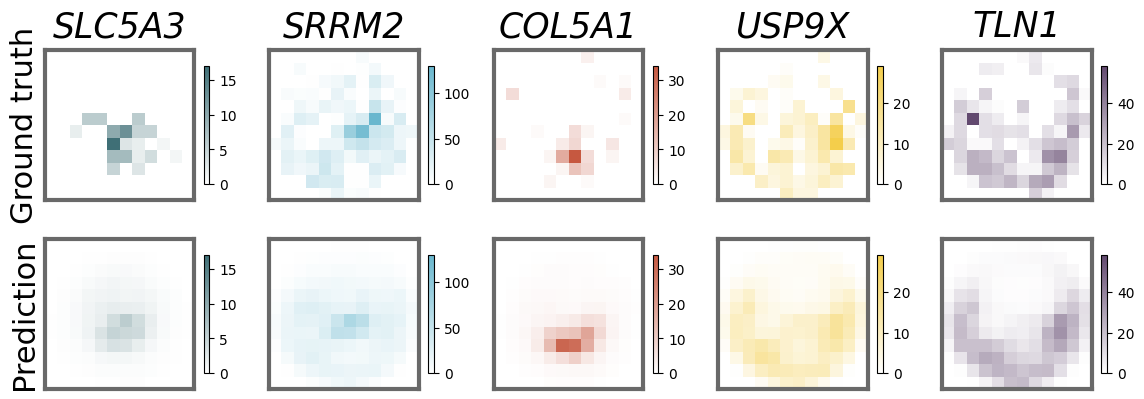

In [2]:
# Fig. 3a
CELL = '37-65'
PANEL_GENES = ['SLC5A3', 'SRRM2', 'COL5A1', 'USP9X', 'TLN1']
PANEL_COLORS = ['#3f6f76', '#69b7ce', '#c65840', '#f4ce4b', '#62496f']

cell_idx = test_cell_names.index(CELL)
fig, ax = plt.subplots(2, 5, figsize=(14, 4.5), gridspec_kw={'hspace': 0.2})

for i, (gene, color) in enumerate(zip(PANEL_GENES, PANEL_COLORS)):
    cmap = LinearSegmentedColormap.from_list('white_to_color', ['white', to_rgba(color)])
    g = gene_names.index(gene)
    measured, predicted = truth_test[cell_idx, g], prediction[cell_idx, g]
    vmax = measured.max()

    for row, image in [(0, measured), (1, predicted)]:
        im = ax[row, i].imshow(image, cmap=cmap, vmin=0, vmax=vmax)
        plt.colorbar(im, shrink=0.75)
        ax[row, i].invert_yaxis()
        ax[row, i].set_xticks([])
        ax[row, i].set_yticks([])
        for spine in ax[row, i].spines.values():
            spine.set_linewidth(3)
            spine.set_color('dimgrey')

    ax[0, i].set_title(gene, fontsize=25, pad=10, fontstyle='italic')

ax[0, 0].set_ylabel('Ground truth', fontsize=22)
ax[1, 0].set_ylabel('Prediction', fontsize=22)

plt.tight_layout()
plt.show()

## Fig. 3b — per-gene performance gains of SVC over the four baseline models, evaluated using PCC, cosine similarity and RMSE

In [3]:
# Fig. 3b
BACKGROUND_PIXELS = [(0, 0), (0, 1), (0, 10), (0, 11), (1, 0), (1, 11),
                     (10, 0), (10, 11), (11, 0), (11, 1), (11, 10), (11, 11)]
SEEDS = range(1, 11)

foreground = np.ones((12, 12), dtype=bool)
for r, c in BACKGROUND_PIXELS:
    foreground[r, c] = False
fg_idx = np.flatnonzero(foreground.reshape(-1))
n_foreground = fg_idx.size

truth_train = np.load(DATA_DIR / 'train_merfish_U2OS.npz', allow_pickle=True)['data_ori']


def cosine_similarity(a, b, eps=1e-8):
    denom = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
    return np.where(denom == 0, 0.0, np.sum(a * b, axis=1) / (denom + eps))


def eval_per_gene(pred):
    """per-gene mean rmse / cosine / pcc over the test cells, foreground pixels only"""
    rmse, cosine, pcc = np.zeros(n_genes), np.zeros(n_genes), np.zeros(n_genes)
    for i in range(n_genes):
        truth_i = truth_test[:, i]
        truth_flat = truth_i.reshape(n_cells, -1)[:, fg_idx]
        pred_flat = pred[:, i].reshape(n_cells, -1)[:, fg_idx]
        non_zero = truth_i.sum((-1, -2)) != 0

        per_cell = [np.corrcoef(pred_flat[j], truth_flat[j])[0, 1] for j in range(n_cells)
                    if non_zero[j] and pred_flat[j].std() > 0 and truth_flat[j].std() > 0]
        rmse[i] = np.sqrt(np.sum((pred_flat - truth_flat) ** 2, axis=1) / n_foreground).mean()
        cosine[i] = cosine_similarity(pred_flat, truth_flat)[non_zero].mean()
        pcc[i] = np.nanmean(per_cell) if per_cell else np.nan
    return rmse, cosine, pcc


def baseline_random_train_cell():
    rows = np.random.randint(0, truth_train.shape[0], size=n_cells)
    return truth_train[rows[:, None], np.arange(n_genes)[None, :]]


def baseline_foreground_shuffle():
    flat = truth_test.reshape(n_cells, n_genes, -1).copy()
    values = flat[:, :, fg_idx]
    order = np.argsort(np.random.rand(n_cells, n_genes, fg_idx.size), axis=-1)
    flat[:, :, fg_idx] = np.take_along_axis(values, order, axis=-1)
    return flat.reshape(truth_test.shape)


b1 = np.zeros((3, len(SEEDS), n_genes))
b2 = np.zeros((3, len(SEEDS), n_genes))
for s in SEEDS:
    np.random.seed(s)
    b1[:, s - 1] = eval_per_gene(baseline_random_train_cell())
    np.random.seed(s)
    b2[:, s - 1] = eval_per_gene(baseline_foreground_shuffle())

b3_pred = np.broadcast_to(truth_train.mean(axis=0)[None, ...], truth_test.shape)
b4_pred = (truth_test.sum(axis=0)[None, ...] - truth_test) / (n_cells - 1)

rmse_svc, cosine_svc, pcc_svc = eval_per_gene(prediction)
rmse_b1, cosine_b1, pcc_b1 = b1.mean(axis=1)
rmse_b2, cosine_b2, pcc_b2 = b2.mean(axis=1)
rmse_b3, cosine_b3, pcc_b3 = eval_per_gene(b3_pred)
rmse_b4, cosine_b4, pcc_b4 = eval_per_gene(b4_pred)


def gains(rmse_b, cosine_b, pcc_b):
    """PCC / cosine gain = difference; RMSE gain = relative reduction. Positive = SVC better."""
    pcc_gain = pcc_svc - pcc_b
    return [pcc_gain[~np.isnan(pcc_gain)],
            cosine_svc - cosine_b,
            -(rmse_svc - rmse_b) / rmse_b]


gains_per_baseline = [gains(rmse_b1, cosine_b1, pcc_b1),
                      gains(rmse_b2, cosine_b2, pcc_b2),
                      gains(rmse_b3, cosine_b3, pcc_b3),
                      gains(rmse_b4, cosine_b4, pcc_b4)]

for name, g in zip(['base1', 'base2', 'base3', 'base4'], gains_per_baseline):
    print(name, ''.join('  %s median %+.3f (frac>0 %.3f)' % (m, np.median(v), np.mean(v > 0))
                        for m, v in zip(['pcc', 'cosine', 'rmse'], g)))

base1   pcc median +0.264 (frac>0 1.000)  cosine median +0.300 (frac>0 1.000)  rmse median +0.296 (frac>0 1.000)
base2   pcc median +0.304 (frac>0 1.000)  cosine median +0.326 (frac>0 1.000)  rmse median +0.320 (frac>0 1.000)
base3   pcc median +0.099 (frac>0 1.000)  cosine median +0.056 (frac>0 1.000)  rmse median +0.034 (frac>0 0.992)
base4   pcc median +0.116 (frac>0 1.000)  cosine median +0.064 (frac>0 1.000)  rmse median +0.038 (frac>0 1.000)


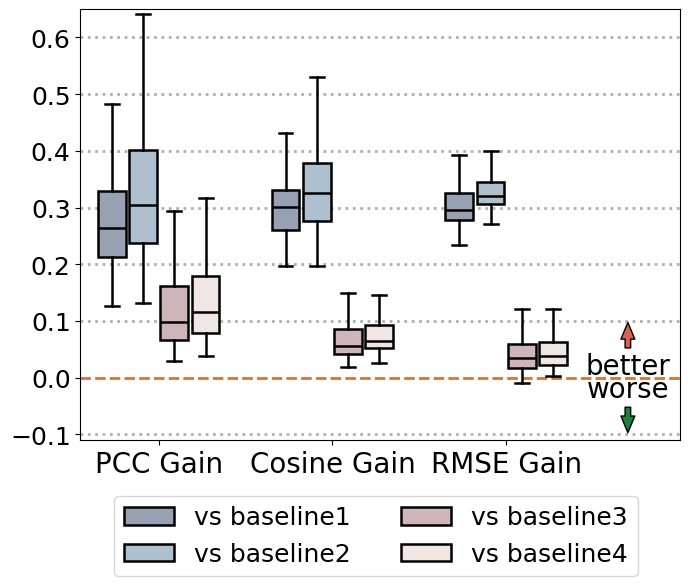

In [4]:
# Fig. 3b
fig, ax = plt.subplots(figsize=(7, 6))

centers = np.array([1, 2, 3])
offsets = np.array([-0.27, -0.09, 0.09, 0.27])
palette = ['#98a1b1', '#aebfce', '#ceb5b9', '#f0e6e4']
common = dict(widths=0.16, zorder=10, notch=False, vert=True, patch_artist=True,
              whiskerprops=dict(color='black', linestyle='-', linewidth=1.8),
              capprops=dict(color='black', linewidth=1.8), showfliers=False)

box_handles = []
for off, color, data in zip(offsets, palette, gains_per_baseline):
    bp = ax.boxplot(data, positions=centers + off,
                    boxprops=dict(facecolor=color, linewidth=1.8),
                    medianprops=dict(linewidth=1.8, color='black'), **common)
    box_handles.append(bp['boxes'][0])

ax.axhline(0, color='#d47838', linestyle='--', linewidth=2)
ax.annotate('better', xy=(3.7, 0.1), xytext=(3.7, 0.02), fontsize=20, ha='center', va='center',
            arrowprops=dict(facecolor='#db614f', shrink=0.05, width=4, headwidth=10))
ax.annotate('worse', xy=(3.7, -0.1), xytext=(3.7, -0.02), fontsize=20, ha='center', va='center',
            arrowprops=dict(facecolor='#1e803d', shrink=0.05, width=4, headwidth=10))

ax.set_xticks(centers)
ax.set_xticklabels(['PCC Gain', 'Cosine Gain', 'RMSE Gain'], fontsize=20)
ax.tick_params(axis='y', labelsize=18)
ax.set_xlim(0.55, 4)
ax.set_ylim(-0.11, 0.65)
ax.set_yticks(np.arange(-0.1, 0.65, 0.1))
ax.grid(axis='y', linestyle=':', linewidth=2)
ax.legend(box_handles, ['vs baseline1', 'vs baseline2', 'vs baseline3', 'vs baseline4'],
          ncol=2, fontsize=18, bbox_to_anchor=(0.95, -0.1))

plt.tight_layout()
plt.show()

## Fig. 3c — SVC-predicted versus observed cell-level expression across all genes, on a log-transformed scale

Pearson correlation is calculated on the original scale.

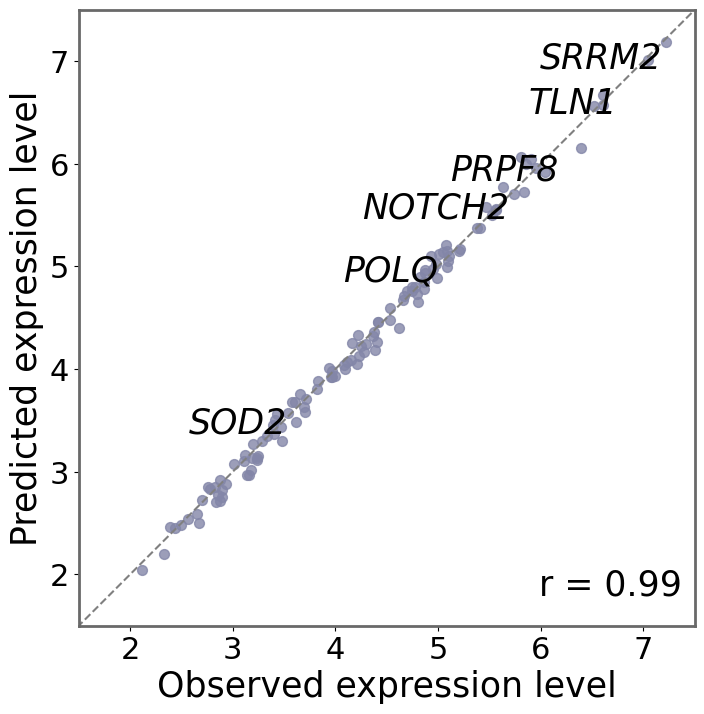

In [5]:
# Fig. 3c
obs_level = truth_test.sum(axis=(-1, -2)).mean(0)
pred_level = prediction.sum(axis=(-1, -2)).mean(0)
labelled_genes = ['NOTCH2', 'TLN1', 'SRRM2', 'POLQ', 'SOD2', 'PRPF8']

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(np.log1p(obs_level), np.log1p(pred_level), s=50, color='#8386A8', alpha=0.8)
ax.text(0.98, 0.05, f'r = {np.corrcoef(obs_level, pred_level)[0, 1]:.2f}',
        transform=ax.transAxes, ha='right', fontsize=25)

for gene in labelled_genes:
    i = gene_names.index(gene)
    ax.annotate(gene, (np.log1p(obs_level[i]), np.log1p(pred_level[i])),
                textcoords='offset points', xytext=(10, -6), ha='right',
                fontsize=25, fontstyle='italic')

ax.plot([0, 8], [0, 8], '--', color='gray')
ax.set_aspect('equal')
ax.set_xlim(1.5, 7.5)
ax.set_ylim(1.5, 7.5)
ax.set_xticks([2, 3, 4, 5, 6, 7])
ax.set_xticklabels([2, 3, 4, 5, 6, 7], fontsize=22)
ax.set_yticks([2, 3, 4, 5, 6, 7])
ax.set_yticklabels([2, 3, 4, 5, 6, 7], fontsize=22)
ax.set_xlabel('Observed expression level', fontsize=25)
ax.set_ylabel('Predicted expression level', fontsize=25)
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('dimgrey')

plt.show()

## Fig. 3d — each gene's SVC-predicted relative distance to the nuclear center against its average log1p-transformed unspliced-to-spliced ratio

In [6]:
from scipy.stats import pearsonr

MIN_COUNTS = 5

_ii, _jj = np.meshgrid(np.arange(12), np.arange(12), indexing='ij')
D = np.sqrt((_ii + 0.5 - 6) ** 2 + (_jj + 0.5 - 6) ** 2) / 6


def distance_ratio(img):
    """Count-weighted mean distance to the grid center, per (cell, gene), capped at 1."""
    total = img.sum(axis=(-1, -2))
    r = np.where(total != 0, (img * D).sum(axis=(-1, -2)) / np.where(total == 0, 1, total), 0.0)
    return np.where(total != 0, np.minimum(r, 1.0), 0.0)


counts = truth_test.sum(axis=(-1, -2))
valid = counts >= MIN_COUNTS
pred_dist = (distance_ratio(prediction) * valid).sum(0) / valid.sum(0)

all_cell_names = np.loadtxt(DATA_DIR / 'cell_names.txt', dtype=str)
splice = np.load(DATA_DIR / 'splice_unsplice.npz')
in_test = np.isin(all_cell_names, test_cell_names)
us_ratio = (np.log1p(splice['unsplice'][in_test]) - np.log1p(splice['splice'][in_test])).mean(0)

corr, pvalue = pearsonr(us_ratio, pred_dist)
print('(cell, gene) images kept: %d / %d | cells per gene %d-%d'
      % (valid.sum(), valid.size, valid.sum(0).min(), valid.sum(0).max()))
print('r = %.4f  (p = %.2e)' % (corr, pvalue))

(cell, gene) images kept: 14247 / 14518 | cells per gene 87-122
r = -0.9248  (p = 6.30e-51)


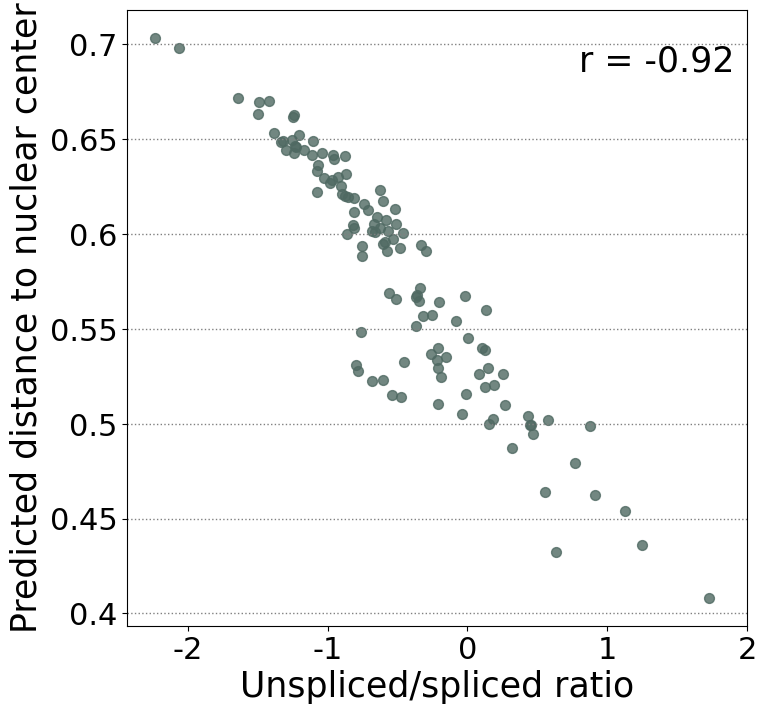

In [7]:
# Fig. 3d
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(us_ratio, pred_dist, s=50, alpha=0.8, color='#4f6962')
ax.text(0.98, 0.9, f'r = {corr:.2f}', transform=ax.transAxes, ha='right', fontsize=25)

ax.set_xticks(np.arange(-2, 2.5, 1))
ax.set_xticklabels([-2, -1, 0, 1, 2], fontsize=22)
ax.set_yticks([0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7])
ax.set_yticklabels([0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7], fontsize=22)
ax.set_xlabel('Unspliced/spliced ratio', fontsize=25)
ax.set_ylabel('Predicted distance to nuclear center', fontsize=25)
ax.grid(axis='y', color='gray', linestyle=':', linewidth=1)

plt.show()

## Fig. 3e — each gene's entropy versus its SVC-predicted relative distance to the nuclear center

Entropy is the normalized Shannon entropy of SVC-predicted expression across image pixels,
ranging from 0 to 1.

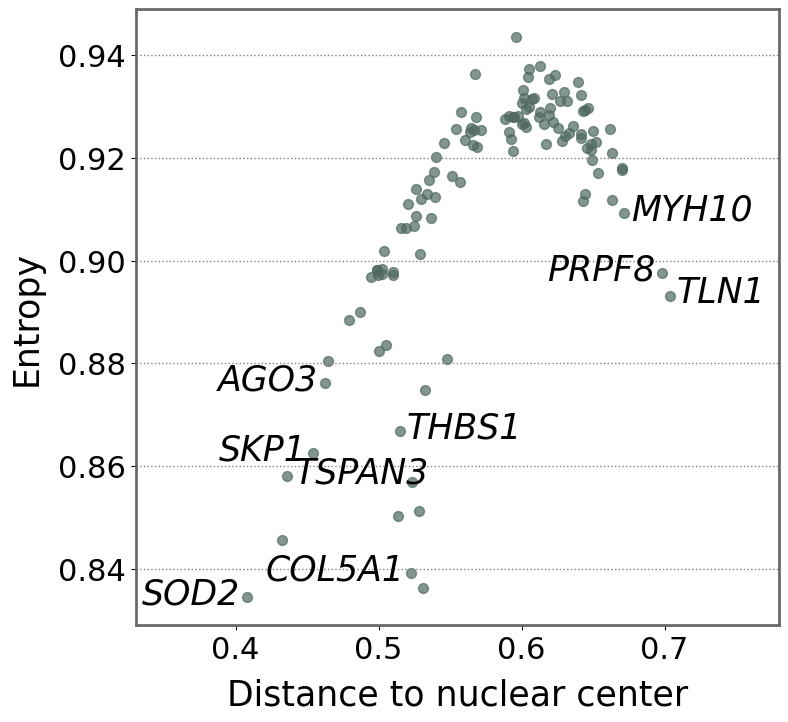

In [8]:
# Fig. 3e
N_FOREGROUND = 132
frac = prediction / prediction.sum(axis=(-1, -2), keepdims=True)
frac = frac.reshape(*frac.shape[:2], -1)
entropy = -(frac * np.log(frac + 1e-10)).sum(-1) / np.log(N_FOREGROUND)
pred_entropy = (entropy * valid).sum(0) / valid.sum(0)

label_left = ['THBS1', 'MYH10', 'TSPAN3', 'TLN1']
label_right = ['COL5A1', 'SKP1', 'PRPF8', 'SOD2', 'AGO3']

fig, ax = plt.subplots(1, 1, figsize=(8.3, 8))
ax.scatter(pred_dist, pred_entropy, alpha=0.7, s=50, c='#4f6962')

for genes, offset, ha in [(label_left, (5, -5), 'left'), (label_right, (-5, -5), 'right')]:
    for gene in genes:
        i = gene_names.index(gene)
        ax.annotate(gene, (pred_dist[i], pred_entropy[i]), textcoords='offset points',
                    xytext=offset, ha=ha, fontsize=25, fontstyle='italic')

ax.grid(axis='y', color='gray', linestyle=':', linewidth=1)
ax.set_xlim(0.33, 0.78)
ax.set_xticks([0.4, 0.5, 0.6, 0.7])
ax.set_xticklabels([0.4, 0.5, 0.6, 0.7], fontsize=22)
ax.tick_params(axis='y', labelsize=22)
ax.set_xlabel('Distance to nuclear center', fontsize=25, labelpad=10)
ax.set_ylabel('Entropy', fontsize=25, labelpad=10)
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('dimgrey')

plt.show()

## Fig. 3f — top 10 genes with the highest subregion-specific enrichment

Enrichment is computed for each gene from its average SVC-predicted transcript expression
within radial subregions from the nuclear center to the cell boundary, across all test cells.
Check marks indicate genes that overlap with the top 10 subregion-specific genes obtained from
the observed real images; stars and triangles denote genes whose encoded protein localizations
in the Human Protein Atlas (HPA) are consistent with the annotated subregions in U2-OS cells or
in other cell lines, respectively.

In [9]:
BACKGROUND_PIXELS = np.array([[0, 0], [0, 1], [0, 10], [0, 11], [1, 0], [1, 11],
                              [10, 0], [10, 11], [11, 0], [11, 1], [11, 10], [11, 11]])
inner = np.zeros((12, 12))
inner[4:8, 4:8] = 1
middle = np.zeros((12, 12))
middle[3:9, 3:9] = 1
middle[2, 4:8] = 1
middle[9, 4:8] = 1
middle = np.maximum(middle, middle.T)
middle[inner == 1] = 0
outer = np.ones((12, 12))
outer[BACKGROUND_PIXELS[:, 0], BACKGROUND_PIXELS[:, 1]] = 0
outer[middle == 1] = 0
outer[inner == 1] = 0
SUBREGIONS = [('inner', inner), ('middle', middle), ('outer', outer)]
print('subregion sizes:', {n: int(m.sum()) for n, m in SUBREGIONS})


def subregion_fraction(img):
    """Fraction of a (cell, gene) map's transcripts falling in each of the three subregions."""
    per_subregion = np.stack([img[:, :, m == 1].sum(-1) for _, m in SUBREGIONS], axis=2)
    return per_subregion / per_subregion.sum(2, keepdims=True)


with np.errstate(invalid='ignore'):
    pred_subregion = np.where(valid[..., None], subregion_fraction(prediction), np.nan)
    truth_subregion = np.where(valid[..., None], subregion_fraction(truth_test), np.nan)
pred_subregion = np.nanmean(pred_subregion, axis=0)          # (n_genes, 3)
truth_subregion = np.nanmean(truth_subregion, axis=0)

HPA_U2OS = [['SKP1', 'TMOD2', 'SRRM2', 'POLQ'],
            ['COL5A1', 'THBS1', 'IGF2R', 'FBN1', 'PLXNA1', 'GPR107', 'SLC7A11'],
            []]
HPA_OTHER = [['TSPAN3', 'AGO3'],
             ['LRP1', 'NOTCH2'],
             ['TLN1', 'RAB3B', 'FASN', 'CKAP5']]

TOP_K = 10
top_genes, marks_real, marks_u2os, marks_other = [], [], [], []
for z, (name, _) in enumerate(SUBREGIONS):
    top_pred = np.array(gene_names)[np.argsort(pred_subregion[:, z])[::-1][:TOP_K]]
    top_real = np.array(gene_names)[np.argsort(truth_subregion[:, z])[::-1][:TOP_K]]
    top_genes.append(list(top_pred))
    for genes, marks in [(top_real, marks_real), (HPA_U2OS[z], marks_u2os), (HPA_OTHER[z], marks_other)]:
        marks += [(list(top_pred).index(g) + TOP_K * z, z) for g in np.intersect1d(top_pred, genes)]
    print('%-6s %s' % (name, ', '.join(top_pred)))

print('marks: measured top-%d %d | HPA U2-OS %d | HPA other %d'
      % (TOP_K, len(marks_real), len(marks_u2os), len(marks_other)))
heatmap_top = np.concatenate([pred_subregion[[gene_names.index(g) for g in gs]] for gs in top_genes])

subregion sizes: {'inner': 16, 'middle': 36, 'outer': 80}
inner  SOD2, TSPAN3, SLC5A3, AGO3, TMOD2, SKP1, YIPF4, RAD51D, SRRM2, FZD5
middle FBN2, COL5A1, LRP1, NOTCH2, THBS1, IGF2R, PLXNA1, FBN1, GPR107, SLC7A11
outer  PRPF8, TLN1, MYH10, FASN, RAB3B, KPNA4, DNAJC13, AGPS, CKAP5, ASCC3
marks: measured top-10 25 | HPA U2-OS 10 | HPA other 8


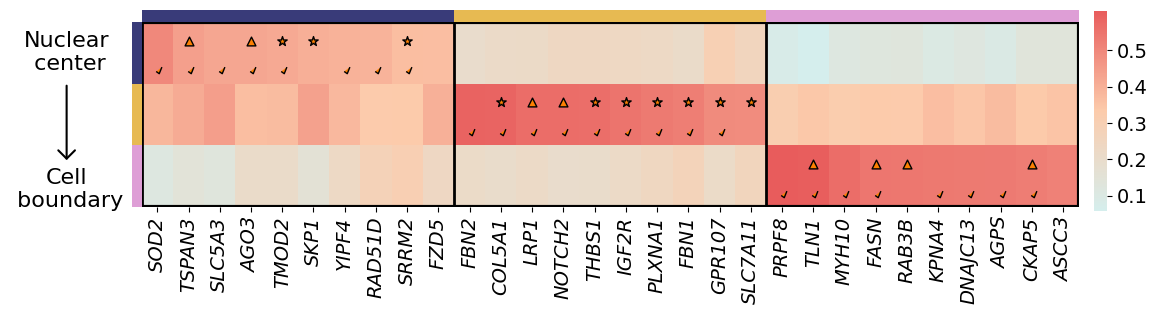

In [10]:
# Fig. 3f
import seaborn as sns
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path as MplPath

cmap = LinearSegmentedColormap.from_list('subregion', ['#D5EEED', '#FCCBAB', '#E85C5C'])
tick_marker = MplPath([(-0.3, 0.0), (0.4, -0.5), (1.0, 1.0)],
                      [MplPath.MOVETO, MplPath.LINETO, MplPath.LINETO])

fig = plt.figure(figsize=(13, 4))
gs = fig.add_gridspec(ncols=4, nrows=3, width_ratios=[0.01, 0.93, 0.05, 0.01],
                      height_ratios=[0.36, 0.04, 0.6], wspace=0, hspace=0)
subregion_index = np.arange(3)

fig.text(0.075, 0.55, 'Nuclear\n center', ha='center', va='top', fontsize=16,
         transform=fig.transFigure)
fig.text(0.075, 0.1, 'Cell\n boundary', ha='center', va='bottom', fontsize=16,
         transform=fig.transFigure)
fig.patches.append(FancyArrowPatch(posA=(0.075, 0.42), posB=(0.075, 0.22),
                                   arrowstyle='->,head_width=0.3,head_length=0.3',
                                   color='black', lw=1.5, transform=fig.transFigure,
                                   mutation_scale=20, figure=fig))

for pos, data in [(gs[2, 0], subregion_index.reshape(-1, 1)), (gs[1, 1], subregion_index.reshape(1, -1))]:
    sns.heatmap(data, cmap='tab20b', ax=fig.add_subplot(pos), cbar=False,
                xticklabels=False, yticklabels=False)

ax_heatmap = fig.add_subplot(gs[2, 1])
ax_cbar = fig.add_subplot(gs[2, 3])
ax_cbar.set_position([0.865, 0.1, 0.01, 0.5])

hm = sns.heatmap(heatmap_top.T, cmap=cmap, yticklabels=[],
                 xticklabels=[g for gs_ in top_genes for g in gs_],
                 ax=ax_heatmap, cbar_ax=ax_cbar, cbar_kws={'shrink': 0.8, 'aspect': 1})
hm.set_xticklabels(hm.get_xticklabels(), fontsize=14, rotation=90, fontstyle='italic')
cbar = hm.collections[0].colorbar
cbar.set_ticks([0.1, 0.2, 0.3, 0.4, 0.5])
cbar.ax.tick_params(labelsize=14)

for x in [0, 10, 20]:
    hm.axvline(x=x, color='black', linewidth=2)
hm.axvline(x=30, color='black', linewidth=3)
hm.axhline(y=0, color='black', linewidth=3)
hm.axhline(y=3, color='black', linewidth=3)

for marks, marker, size, dy, zorder in [(marks_u2os, '*', 50, 0.3, 20),
                                        (marks_other, '^', 40, 0.3, None),
                                        (marks_real, tick_marker, 40, 0.8, None)]:
    for x, y in marks:
        kw = {'zorder': zorder} if zorder is not None else {}
        hm.scatter(x + 0.5, y + dy, marker=marker, color='#fc8002', s=size,
                   edgecolors='black', **kw)

plt.show()

## Fig. 3g — UMAP of the cell clustering results from SVC

For each cell, the gene-gene cosine similarity matrix computed from its inferred latent
representation is flattened into a feature vector and used as input to UMAP. The cluster labels
are shipped in `precomputed/subcluster_labels.npy`.

cells 900 | clusters [0, 1, 2, 3] | sizes [288, 291, 294, 27]


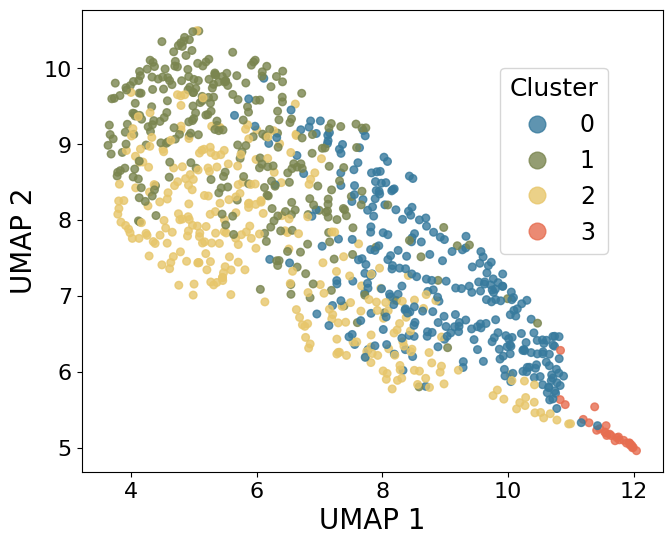

In [11]:
# Fig. 3g
import umap
from matplotlib.colors import ListedColormap

_c = np.load(HERE / 'precomputed/cell_gene_cosine_train.npz', allow_pickle=True)
cosine_flat = _c['cosine']                                   # (n_train_cells, 119 * 119)
cluster_labels = np.load(HERE / 'precomputed/subcluster_labels.npy')
CLUSTERS = sorted(np.unique(cluster_labels).tolist())
CLUSTER_COLORS = ['#377A9D', '#7A854F', '#e7c66b', '#e66d50']
print('cells %d | clusters %s | sizes %s'
      % (len(cluster_labels), CLUSTERS, np.bincount(cluster_labels).tolist()))

reducer = umap.UMAP(random_state=1)
coords = reducer.fit_transform(cosine_flat)

fig = plt.figure(figsize=(7.5, 6))
sc = plt.scatter(coords[:, 1], coords[:, 0], alpha=0.8, s=30,
                 c=cluster_labels, cmap=ListedColormap(CLUSTER_COLORS))
handles, _ = sc.legend_elements()
plt.legend(handles, CLUSTERS, title='Cluster', bbox_to_anchor=(0.7, 0.9), loc='upper left',
           fontsize=17, title_fontsize=18, markerscale=2)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('UMAP 1', fontsize=20)
plt.ylabel('UMAP 2', fontsize=20)

plt.show()

## Fig. 3h — average relative distance to the nuclear center (left) and log1p-transformed unspliced/spliced expression ratio (right) across genes, in each of the clusters 0-3

P values from one-sided Wilcoxon signed-rank tests.

In [12]:
from scipy.stats import wilcoxon

train_data = np.load(DATA_DIR / 'train_merfish_U2OS.npz', allow_pickle=True)
truth_train = train_data['data_ori']
train_cell_names = train_data['cell_names'].astype(str)

train_valid = truth_train.sum(axis=(-1, -2)) >= MIN_COUNTS
train_dist = distance_ratio(truth_train)
in_train = np.isin(all_cell_names, train_cell_names)
train_us = np.log1p(splice['unsplice'][in_train]) - np.log1p(splice['splice'][in_train])

dist_by_cluster, us_by_cluster = [], []
for k in CLUSTERS:
    m = cluster_labels == k
    dist_by_cluster.append((train_dist[m] * train_valid[m]).sum(0) / train_valid[m].sum(0))
    us_by_cluster.append(train_us[m].mean(0))

p_dist = [wilcoxon(dist_by_cluster[0], dist_by_cluster[k], alternative='greater')[1] for k in [1, 2, 3]]
p_us = [wilcoxon(us_by_cluster[k], us_by_cluster[0], alternative='greater')[1] for k in [1, 2, 3]]

print('(cell, gene) images kept: %d / %d' % (train_valid.sum(), train_valid.size))
print('median distance ', ['%.4f' % np.median(x) for x in dist_by_cluster])
print('median US ratio ', ['%.4f' % np.median(x) for x in us_by_cluster])
print('p distance 0>k  ', ['%.2e' % p for p in p_dist])
print('p US ratio  k>0 ', ['%.2e' % p for p in p_us])

(cell, gene) images kept: 102348 / 107100
median distance  ['0.5973', '0.5903', '0.5959', '0.5515']
median US ratio  ['-0.7097', '-0.6140', '-0.6161', '-0.1647']
p distance 0>k   ['3.38e-16', '1.39e-02', '1.20e-12']
p US ratio  k>0  ['6.19e-10', '4.10e-11', '3.48e-19']


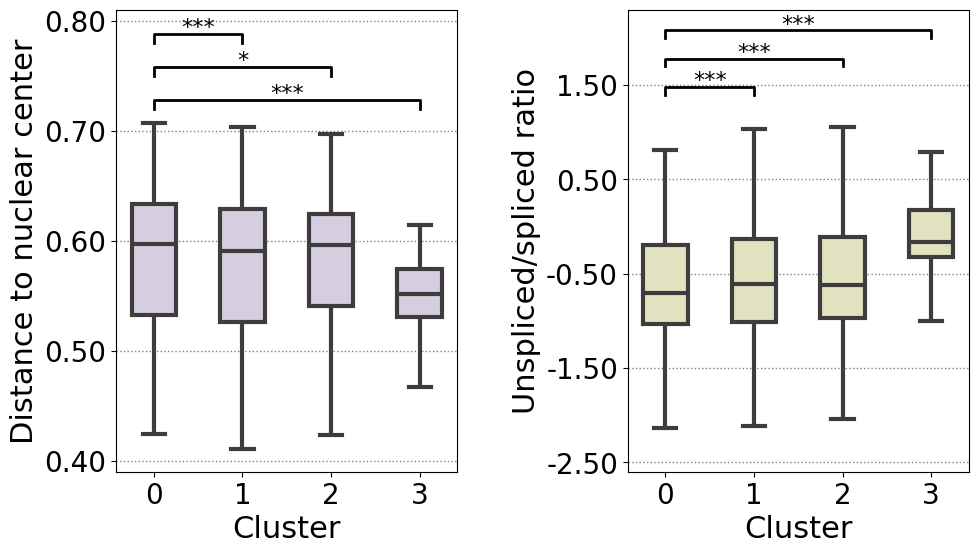

In [13]:
# Fig. 3h
def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'

PANELS = [(dist_by_cluster, p_dist, '#D7CAE4', 'Distance to nuclear center',
           (0.39, 0.81), np.arange(0.4, 0.82, 0.1), [0.78, 0.75, 0.72], 0.008),
          (us_by_cluster, p_us, '#e8e7bb', 'Unspliced/spliced ratio',
           (-2.6, 2.3), np.arange(-2.5, 2.5, 1), [1.4, 1.7, 2], 0.08)]

fig, ax = plt.subplots(1, 2, figsize=(11, 6), gridspec_kw={'wspace': 0.5})

for a, (values, pvals, color, ylabel, ylim, yticks, bracket_y, tick) in zip(ax, PANELS):
    sns.boxplot(data=values, color=color, width=0.5, linewidth=3, showfliers=False, ax=a, zorder=10)
    a.set_ylim(*ylim)
    a.set_yticks(yticks)
    a.set_yticklabels(['%.2f' % t for t in yticks], fontsize=20)
    a.set_xticks(CLUSTERS)
    a.set_xticklabels(CLUSTERS, fontsize=20)
    a.set_ylabel(ylabel, fontsize=22)
    a.grid(axis='y', color='gray', linestyle=':', linewidth=1)

    for k, (p, y) in enumerate(zip(pvals, bracket_y), start=1):
        a.plot([0, 0, k, k], [y, y + tick, y + tick, y], color='black', lw=2, clip_on=False)
        a.text(k / 2, y + tick, stars(p), size=16, ha='center')
ax[0].set_xlabel('Cluster', fontsize=22)
ax[1].set_xlabel('Cluster', fontsize=22)

plt.show()

## Fig. 3i — gene co-localization network for the top 50 gene pairs in each cell cluster

Edge colors denote the cluster assignment of each identified gene pair; gene pairs shared among
all clusters are connected by purple edges.

In [14]:
K_NN = 10
TOP_PAIRS = 50
DETECT = 1

cosine_per_cell = cosine_flat.reshape(-1, n_genes, n_genes)
train_counts = truth_train.sum(axis=(-1, -2))

pairs_per_cluster = []
for k in CLUSTERS:
    cells = np.flatnonzero(cluster_labels == k)
    detected = train_counts[cells] >= DETECT
    coloc = np.zeros((n_genes, n_genes))
    for n, c in enumerate(cells):
        neighbours = np.argsort(1.0 - cosine_per_cell[c], axis=1)[:, 1:K_NN + 1]
        rows = np.flatnonzero(detected[n])
        coloc[rows[:, None], neighbours[rows]] += 1
    coloc /= np.maximum(detected.sum(0), 1)[:, None]
    coloc = np.triu(np.maximum(coloc, coloc.T), 1)

    pairs = []
    for _ in range(TOP_PAIRS):
        i, j = np.unravel_index(np.argmax(coloc), coloc.shape)
        pairs.append((gene_names[i], gene_names[j]))
        coloc[i, j] = 0
    pairs_per_cluster.append(pairs)

union_pairs = sorted(set().union(*[set(p) for p in pairs_per_cluster]))
pair_clusters = {p: [k for k in CLUSTERS if p in pairs_per_cluster[k]] for p in union_pairs}
n_four = sum(1 for c in pair_clusters.values() if len(c) == len(CLUSTERS))
n_specific = [sum(1 for c in pair_clusters.values() if c == [k]) for k in CLUSTERS]
print('union %d pairs over %d genes | in all four clusters: %d'
      % (len(union_pairs), len({g for p in union_pairs for g in p}), n_four))
print('number of cluster 0/1/2/3 specific pairs:', *n_specific)

union 76 pairs over 27 genes | in all four clusters: 25
number of cluster 0/1/2/3 specific pairs: 1 0 1 19


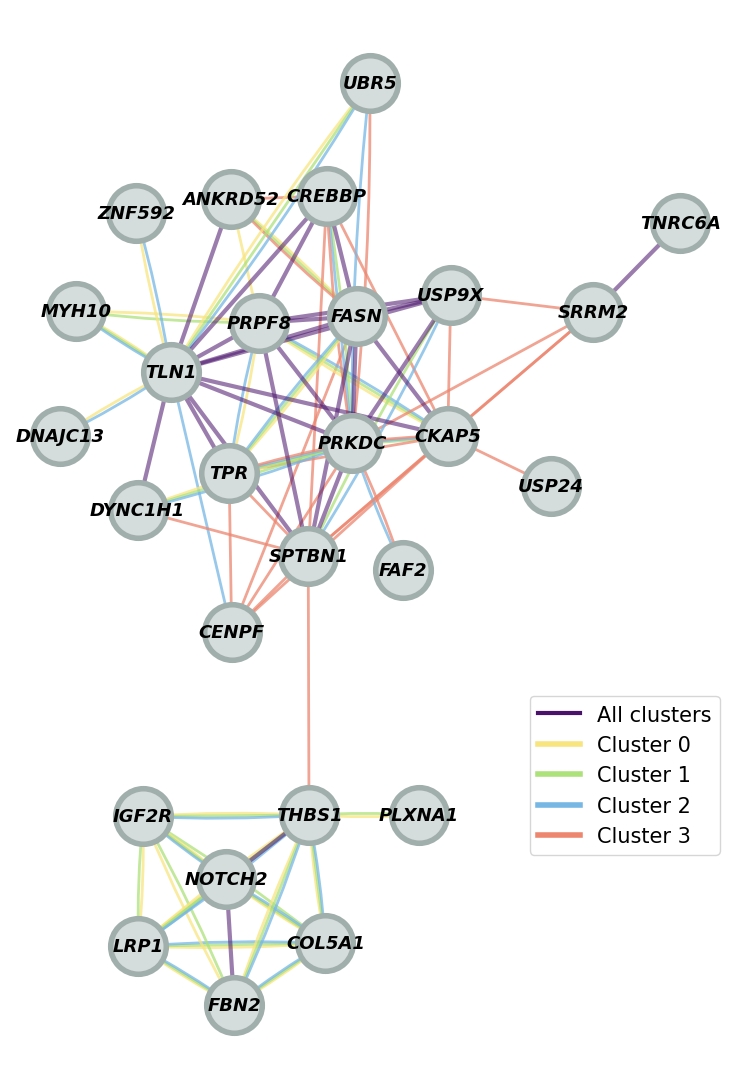

In [15]:
# Fig. 3i
import networkx as nx
from matplotlib.lines import Line2D

EDGE_COLORS = ['#F8E57F', '#ADE17A', '#76B7E4', '#EC866F']
SHARED_COLOR, SHARED_WIDTH, SHARED_ALPHA = "#4A126B", 3, 0.55
CLUSTER_WIDTH, CLUSTER_ALPHA, ARC = 2.0, 0.75, 0.03

graph = nx.Graph()
graph.add_edges_from(union_pairs)

layout = np.load(HERE / 'precomputed/network_layout.npz')
pos = dict(zip(layout['genes'].tolist(), map(tuple, layout['xy'])))
assert set(pos) == set(graph)

fig, ax = plt.subplots(figsize=(7.5, 11))
for (u, v), clusters in pair_clusters.items():
    if len(clusters) == len(CLUSTERS):
        continue
    rads = [0.0] if len(clusters) == 1 else np.linspace(-ARC, ARC, len(clusters))
    for k, rad in zip(clusters, rads):
        ax.add_patch(FancyArrowPatch(pos[u], pos[v], connectionstyle=f'arc3,rad={rad}',
                                     arrowstyle='-', linewidth=CLUSTER_WIDTH, color=EDGE_COLORS[k],
                                     alpha=CLUSTER_ALPHA, zorder=1))
for (u, v), clusters in pair_clusters.items():
    if len(clusters) == len(CLUSTERS):
        ax.add_patch(FancyArrowPatch(pos[u], pos[v], arrowstyle='-', linewidth=SHARED_WIDTH,
                                     color=SHARED_COLOR, alpha=SHARED_ALPHA, zorder=2))

nodes = nx.draw_networkx_nodes(graph, pos, node_color='#D4DDDC', node_size=1600,
                               edgecolors='#A1AFAC', linewidths=4, ax=ax,)
nodes.set_zorder(3)
for text in nx.draw_networkx_labels(graph, pos, font_size=13, font_color='black',
                                    font_weight='bold', ax=ax).values():
    text.set_fontstyle('italic')
    text.set_zorder(4)

ax.legend([Line2D([0], [0], color=SHARED_COLOR, lw=SHARED_WIDTH)]
          + [Line2D([0], [0], color=EDGE_COLORS[k], lw=4) for k in CLUSTERS],
          ['All clusters'] + ['Cluster %d' % k for k in CLUSTERS], fontsize=15,
          loc='lower right', bbox_to_anchor=(1.0, 0.20))
ax.margins(0.08)
ax.set_axis_off()

plt.tight_layout()
plt.show()

## Fig. 3j — observed transcript profiles in the original cells for three representative co-localized gene pairs shared by all cell clusters

Top panels show cells from clusters 0, 1 and 2; bottom panels show three example cells from the
abnormal cluster 3.

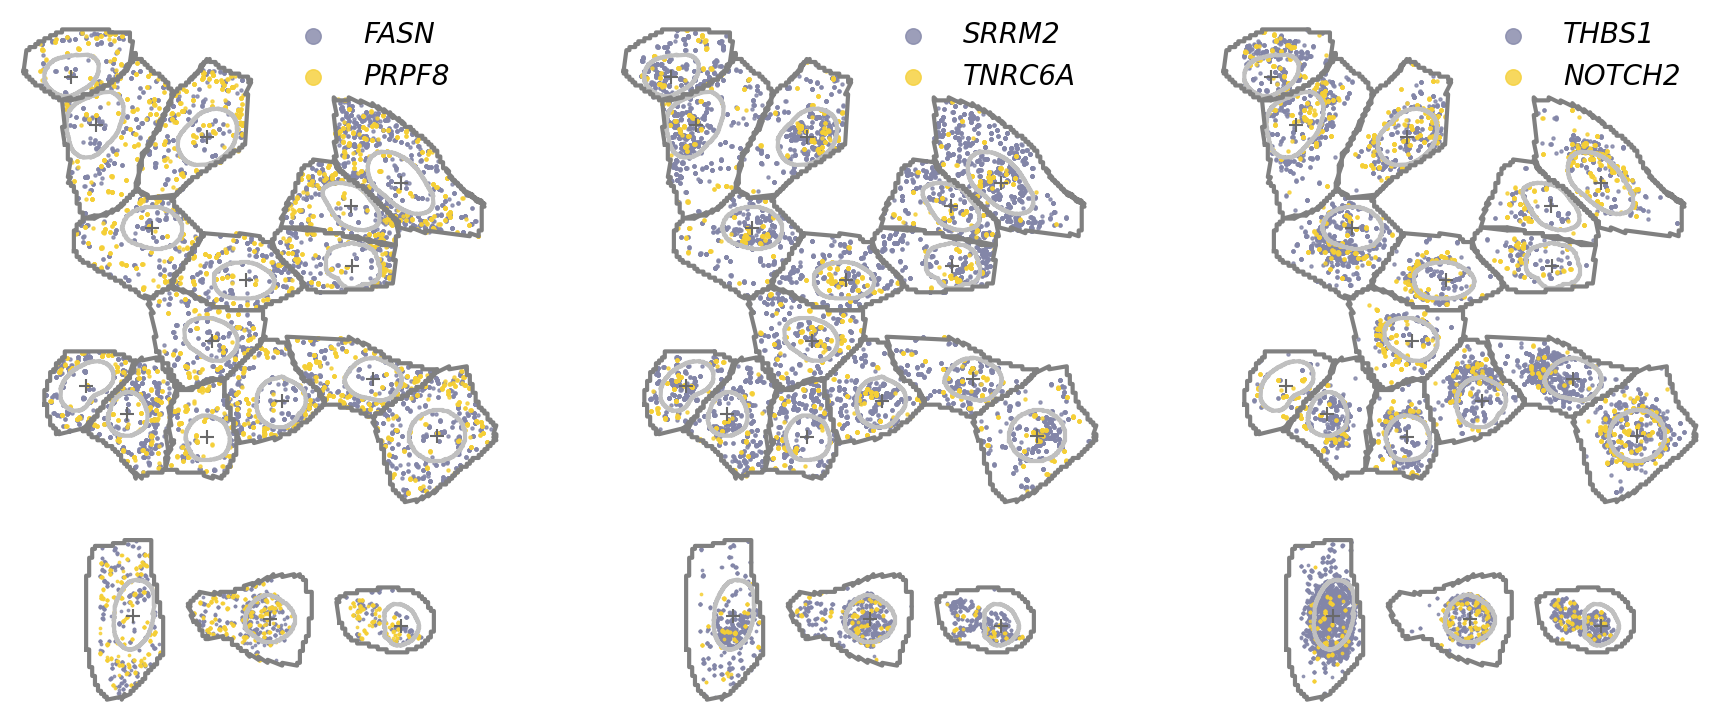

In [16]:
# Fig. 3j
import pandas as pd

PAIRS = [('FASN', 'PRPF8'), ('SRRM2', 'TNRC6A'), ('THBS1', 'NOTCH2')]
PAIR_COLORS = ['#8386a8', '#f5cf36']
FOV = '0'
CLUSTER_3_CELLS = ['31-7', '33-35', '0-32']
FOV_WINDOW, CELL_PAD = 1980.0, 25.0
TOP_INCHES, GAP_X, GAP_ROW, CELL_GAP, MARGIN = 5.0, 1, 0.18, 0.12, 0.06

transcripts = pd.read_csv(HERE / 'precomputed/fig3j_transcripts.csv.gz')
cell_contour = pd.read_csv(HERE / 'precomputed/fig3j_cell_contour.csv.gz')
nuclear_contour = pd.read_csv(HERE / 'precomputed/fig3j_nuclear_contour.csv.gz')

names = list(train_cell_names)
assert all(cluster_labels[names.index(c)] == 3 for c in CLUSTER_3_CELLS)

def closed_contour(points):
    """order cell boundary points by polar angle and close them"""
    center = points.mean(axis=0)
    order = np.argsort(np.arctan2(points[:, 1] - center[1], points[:, 0] - center[0]))
    return np.vstack([points[order], points[order][0]])

def window(cells, pad):
    """data limits that just contain the cells and their transcripts"""
    box = cell_contour[cell_contour.cell.isin(cells)]
    dots = transcripts[transcripts.cell.isin(cells)]
    return (min(box.x.min(), dots.x.min()) - pad, max(box.x.max(), dots.x.max()) + pad,
            min(box.y.min(), dots.y.min()) - pad, max(box.y.max(), dots.y.max()) + pad)

def draw(ax, cells, pair, size, limits):
    for gene, color in zip(pair, PAIR_COLORS):
        g = transcripts[transcripts.cell.isin(cells) & (transcripts.gene == gene)]
        ax.scatter(g['x'], g['y'], label=gene, alpha=0.8, s=size, color=color)
    for cell in cells:
        boundary = cell_contour[cell_contour.cell == cell]
        nucleus = nuclear_contour[nuclear_contour.cell == cell]
        ax.plot(*closed_contour(nucleus[['x', 'y']].values).T, color='silver', linewidth=3)
        ax.plot(*closed_contour(boundary[['x', 'y']].values).T, color='grey', linewidth=3)
        ax.scatter(boundary['centerX'].iloc[:1], boundary['centerY'].iloc[:1],
                   marker='+', color='dimgray', s=100)
    ax.set_xlim(limits[0], limits[1])
    ax.set_ylim(limits[2], limits[3])
    ax.set_aspect('equal')
    ax.axis('off')

units_per_inch = FOV_WINDOW / TOP_INCHES
fov_cells = [c for c in cell_contour.cell.unique() if c.split('-')[1] == FOV]
fov_limits = window(fov_cells, (FOV_WINDOW - 1872) / 2)

cell_limits = [window([c], CELL_PAD) for c in CLUSTER_3_CELLS]
cell_boxes = [((x1 - x0) / units_per_inch, (y1 - y0) / units_per_inch)
              for x0, x1, y0, y1 in cell_limits]
group_inches = sum(w for w, _ in cell_boxes) + 2 * CELL_GAP
row_inches = max(h for _, h in cell_boxes)
width = 2 * MARGIN + 3 * TOP_INCHES + 2 * GAP_X 
height = 2 * MARGIN + TOP_INCHES + GAP_ROW + row_inches

fig = plt.figure(figsize=(width, height))
for i, pair in enumerate(PAIRS):
    left = MARGIN + i * (TOP_INCHES + GAP_X)
    ax = fig.add_axes([left / width, (MARGIN + row_inches + GAP_ROW) / height,
                       TOP_INCHES / width, TOP_INCHES / height])
    draw(ax, fov_cells, pair, 5, fov_limits)
    legend = ax.legend(fontsize=20, markerscale=5, bbox_to_anchor=(0.5, 0.8), frameon=False)
    for text in legend.get_texts():
        text.set_fontstyle('italic')

    offset = left + (TOP_INCHES - group_inches) / 2
    for cell, limits, (box_w, box_h) in zip(CLUSTER_3_CELLS, cell_limits, cell_boxes):
        ax = fig.add_axes([offset / width, (MARGIN + (row_inches - box_h) / 2) / height,
                           box_w / width, box_h / height])
        draw(ax, [cell], pair, 3, limits)
        offset += box_w + CELL_GAP

scales = {(round((a.get_xlim()[1] - a.get_xlim()[0]) / (a.get_position().width * width), 4),
           round((a.get_ylim()[1] - a.get_ylim()[0]) / (a.get_position().height * height), 4))
          for a in fig.axes}
assert scales == {(units_per_inch, units_per_inch)}, scales

plt.show()